### Contexto 

Para tentar entender quais as características que fazem um funcionário ficar ou deixar uma empresa de Tecnologia, o RH desta empresa catalogou informações de 1470 funcionários que deixaram ou permaneceram na companhia no último ano. O resultado desse levantamento gerou 19 possíveis fatores que explicam o comportamento do turnover. Para conhecer esses fatores, verifique a tabela de metadados existente na guia Metadados.

Com base nisso, responder a seguinte pergunta:

Quais políticas/fatores da empresa deveriam mudar de forma a minimizar o turnover?

Análise Exploratória de Dados:

Construir tabelas de frequências absolutas e relativas para as variáveis qualitativas.
Construir tabelas e/ou box-plots com medidas resumo para as variáveis quantitativas.
Verificar a taxa de turnover atual (% pessoas que saíram / total de funcionários).
Quais foram os insights obtidos com a realização dessas análises?
Análise Bidimensional

A taxa de turnover é maior em algum grupo especifico? Ex: Calcular o turnover para cada uma das variáveis qualitativas e investigar as diferenças.
O turnover tem relação com alguma variável quantitativa? Ex: O turnover é maior para quem ganha menos? Ou quem tem mais idade?
Utilize as técnicas de análise bidimensional para avaliar a associação entre a variável turnover e as demais variáveis. 
Após realizar essas análises é possível sugerir alguma mudança para reduzir o turnover? Descreva e fundamente suas sugestões.

### Carregamento de pacote

In [20]:
# Pacotes de preparação dos dados
import numpy as np
import pandas as pd

# Pacotes gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9
from plotnine import ggplot, aes, geom_bar, facet_wrap, labs, scale_x_discrete, theme, element_text
# Pacotes de modelagem
from scipy.stats import kruskal
import scipy.stats as stats

# Módulo de Análise Exploratória
import aed
from ydata_profiling import ProfileReport

### Leitura banco de dados.

In [3]:
base=pd.read_excel('Base_RH.xlsx', sheet_name=1)

In [26]:
base

,ID,Funcionário_deixou_a_empresa,Idade,Frequência de Viagens,Distância_do_trabalho,Formação,E-Sat,Gênero,Estado_Civil,Salário,...,Faz_hora_extras?,Perc_de_aumento,Qte_ações_da_empresa,Tempo_de_carreira,Horas_de_treinamento,Equilibrio_de_Vida,Tempo_de_empresa,Anos_no_mesmo_cargo,Anos_desde_a_ultima_promocao,Anos_com_o_mesmo_chefe
0,1,Sim,41,Viaja raramente,1,Ensino Técnico,Médio,M,Solteiro,5993,...,Sim,11,0,8,0,Ruim,6,4,0,5
1,2,Não,49,Viaja frequentemente,8,Ensino Médio,Alto,H,Casado,5130,...,Não,23,1,10,3,Muito bom,10,7,1,7
2,3,Sim,37,Viaja raramente,2,Ensino Técnico,Muito Alto,H,Solteiro,2090,...,Sim,15,0,7,3,Muito bom,0,0,0,0
3,4,Não,33,Viaja frequentemente,3,Mestrado,Muito Alto,M,Casado,2909,...,Sim,11,0,8,3,Muito bom,8,7,3,0
4,5,Não,27,Viaja raramente,2,Ensino Médio,Baixo,H,Casado,3468,...,Não,12,1,6,3,Muito bom,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,1466,Não,36,Viaja frequentemente,23,Ensino Técnico,Alto,H,Casado,2571,...,Não,17,1,17,3,Muito bom,5,2,0,3
1466,1467,Não,39,Viaja raramente,6,Ensino Médio,Muito Alto,H,Casado,9991,...,Não,15,1,9,5,Muito bom,7,7,1,7
1467,1468,Não,27,Viaja raramente,4,Ensino Superior,Médio,H,Casado,6142,...,Sim,20,1,6,0,Muito bom,6,2,0,3
1468,1469,Não,49,Viaja frequentemente,2,Ensino Superior,Muito Alto,H,Casado,5390,...,Não,14,0,17,3,Bom,9,6,0,8


Usando coluna alvo: Funcionário_deixou_a_empresa


### Ajuste do banco de dados.

O banco de dados conta com 22 variáveis sendo 8 delas categóricas e 14 contínuas. Os nomes das variáveis são apresentados a baixo.  

In [58]:
#base.dtypes
#base.columns
#base.isnull().sum()
#base.index.duplicated().sum()
base.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   ID                            1470 non-null   int64 
 1   Funcionario_deixou_a_empresa  1470 non-null   object
 2   Idade                         1470 non-null   int64 
 3   Frequência de Viagens         1470 non-null   object
 4   Distância_do_trabalho         1470 non-null   int64 
 5   Formação                      1470 non-null   object
 6   E-Sat                         1470 non-null   object
 7   Gênero                        1470 non-null   object
 8   Estado_Civil                  1470 non-null   object
 9   Salário                       1470 non-null   int64 
 10  Qte_Empresas_Trabalhadas      1470 non-null   int64 
 11  Faz_hora_extras?              1470 non-null   object
 12  Perc_de_aumento               1470 non-null   int64 
 13  Qte_ações_da_empre

### Analise exploratoria

A partir da análise exploratória observamos que a empresa possui uma taxa de turnover de 16%.

Observamos também a partir dos histogramas uma diferença grande nas categorias das variáveis horas extra e estado civil e depois confirmada pela análise IV.


#### Turn over total (%)

In [11]:
contagem_tot= base['Funcionário_deixou_a_empresa'].value_counts()
contagem_tot

Não    1233
Sim     237
Name: Funcionario_deixou_a_empresa, dtype: int64

In [61]:
237/(1233+237)

0.16122448979591836

#### Analise IV 

In [24]:
# Converter a coluna para o tipo inteiro
base2=base.copy()
base2['Funcionário_deixou_a_empresa'] = base2['Funcionário_deixou_a_empresa'].replace({'Sim': 1, 'Não': 0})
base2['Funcionário_deixou_a_empresa'] = base2['Funcionário_deixou_a_empresa'].astype(int)


dados_iv = aed.analise_iv(base2,'Funcionário_deixou_a_empresa',nbins=10)
dados_iv.get_lista_iv()

C:\Users\tania\Desktop\Git-Hub\People_Analytics\People_Analytics\aed.py:110: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Funcionário_deixou_a_empresa,IV
Variavel,
Salário,0.42
Faz_hora_extras?,0.40
Tempo_de_empresa,0.34
Tempo_de_carreira,0.34
Idade,0.31
Anos_no_mesmo_cargo,0.27
Anos_com_o_mesmo_chefe,0.26
Estado_Civil,0.22
Frequência de Viagens,0.13


In [36]:
dados_iv.get_bivariada(var_escolhida='Faz_hora_extras?')

==> "Faz_hora_extras?" tem IV de 0.4


Funcionário_deixou_a_empresa,Variavel,Var_Range,#Target_1,#Target_0,Total,%Freq,%Target_1,%Target_0,%Taxa_de_Target_1,Odds,LN(Odds),IV
0,Faz_hora_extras?,Não,110,944,1054,71.7,46.41,76.56,10.44,0.61,-0.49,0.15
1,Faz_hora_extras?,Sim,127,289,416,28.3,53.59,23.44,30.53,2.29,0.83,0.25


In [37]:
dados_iv.get_bivariada(var_escolhida='Frequência de Viagens')

==> "Frequência de Viagens" tem IV de 0.13


Funcionário_deixou_a_empresa,Variavel,Var_Range,#Target_1,#Target_0,Total,%Freq,%Target_1,%Target_0,%Taxa_de_Target_1,Odds,LN(Odds),IV
0,Frequência de Viagens,Não viaja,12,138,150,10.20,5.06,11.19,8.00,0.45,-0.80,0.05
1,Frequência de Viagens,Viaja frequentemente,69,208,277,18.84,29.11,16.87,24.91,1.73,0.55,0.07
2,Frequência de Viagens,Viaja raramente,156,887,1043,70.95,65.82,71.94,14.96,0.91,-0.09,0.01


In [38]:
dados_iv.get_bivariada(var_escolhida='E-Sat')

==> "E-Sat" tem IV de 0.1


Funcionário_deixou_a_empresa,Variavel,Var_Range,#Target_1,#Target_0,Total,%Freq,%Target_1,%Target_0,%Taxa_de_Target_1,Odds,LN(Odds),IV
0,E-Sat,Alto,62,391,453,30.82,26.16,31.71,13.69,0.82,-0.20,0.01
1,E-Sat,Baixo,72,212,284,19.32,30.38,17.19,25.35,1.77,0.57,0.08
2,E-Sat,Muito Alto,60,386,446,30.34,25.32,31.31,13.45,0.81,-0.21,0.01
3,E-Sat,Médio,43,244,287,19.52,18.14,19.79,14.98,0.92,-0.08,0.00


In [39]:
dados_iv.get_bivariada(var_escolhida='Estado_Civil')

==> "Estado_Civil" tem IV de 0.22


Funcionário_deixou_a_empresa,Variavel,Var_Range,#Target_1,#Target_0,Total,%Freq,%Target_1,%Target_0,%Taxa_de_Target_1,Odds,LN(Odds),IV
0,Estado_Civil,Casado,84,589,673,45.78,35.44,47.77,12.48,0.74,-0.30,0.04
1,Estado_Civil,Divorciado,33,294,327,22.24,13.92,23.84,10.09,0.58,-0.54,0.05
2,Estado_Civil,Solteiro,120,350,470,31.97,50.63,28.39,25.53,1.78,0.58,0.13


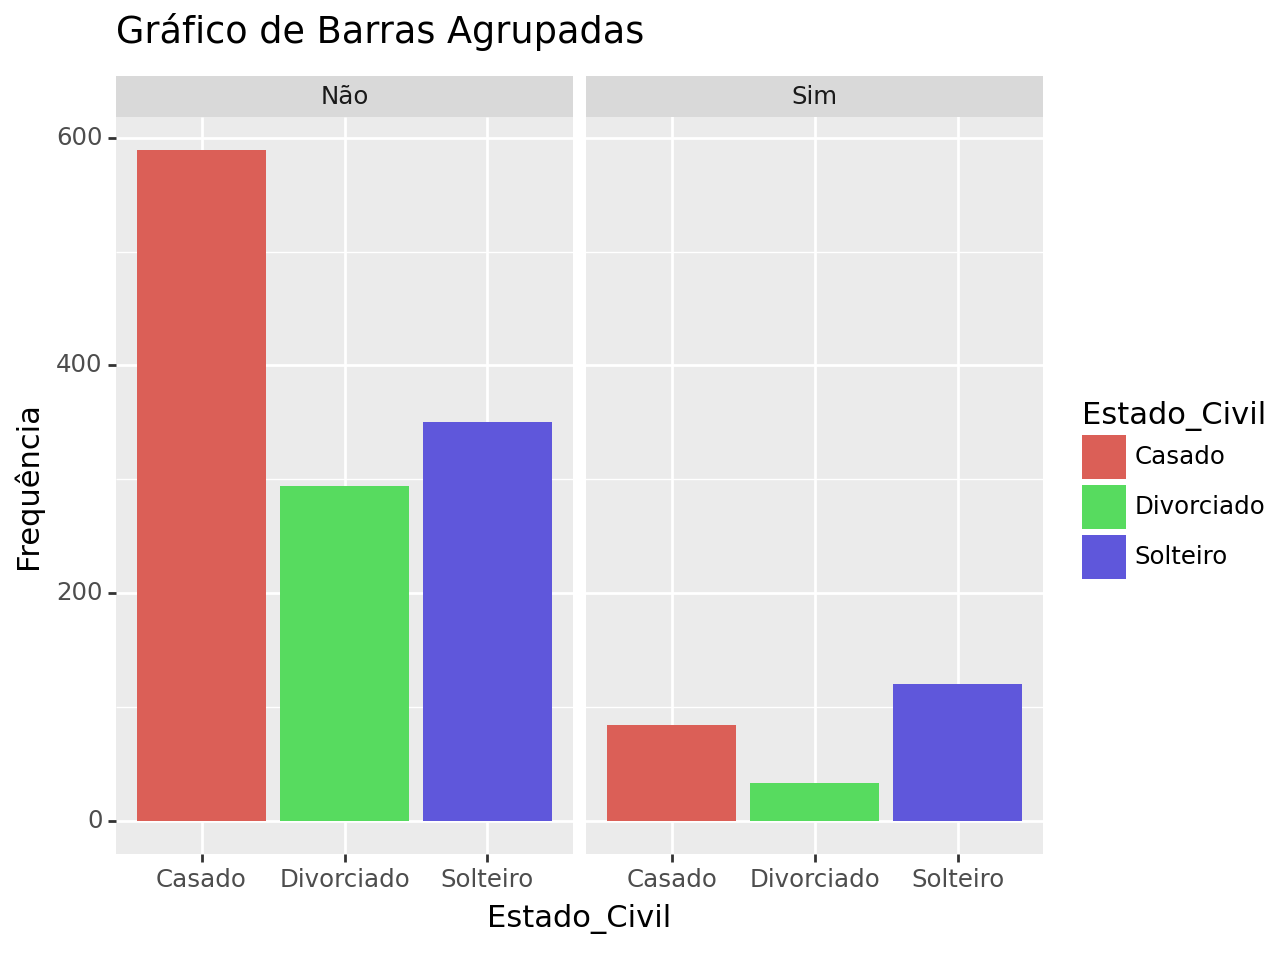

In [4]:
from plotnine import ggplot, aes, geom_bar, facet_wrap, scale_x_discrete, labs
from textwrap import wrap

# Criando o gráfico de barras agrupadas
grafico = (
    ggplot(base, aes(x='Estado_Civil', fill='Estado_Civil')) + 
    geom_bar(position='dodge') + 
    labs(title='Gráfico de Barras Agrupadas', x='Estado_Civil', y='Frequência') +
    facet_wrap('Funcionário_deixou_a_empresa')
)

# Mostrando o gráfico
print(grafico)
# geom_bar(position='dodge') para criar barras agrupadas. A estética fill agrupa as barras de acordo com a coluna Funcionario_deixou_a_empresa, e a função facet_wrap() divide o gráfico em duas partes, uma para funcionários que deixaram a empresa ('1') e outra para funcionários que não deixaram a empresa ('0')

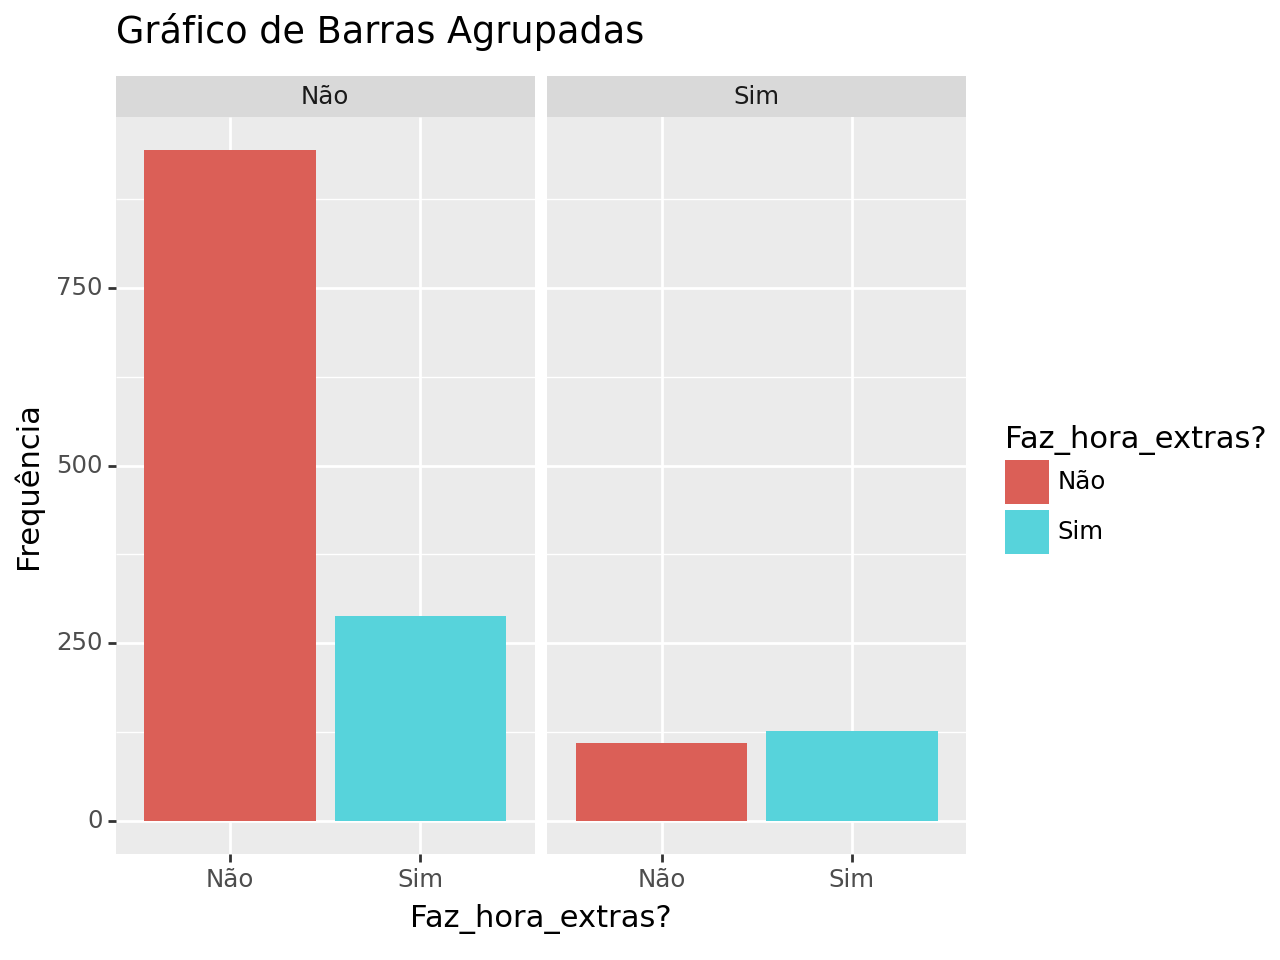

In [4]:
# Criando o gráfico de barras agrupadas
import matplotlib.pyplot as plt
from plotnine import ggplot, aes, geom_bar, facet_wrap, scale_x_discrete, labs
from textwrap import wrap
grafico = (
    ggplot(base, aes(x='Faz_hora_extras?', fill='Faz_hora_extras?')) + 
    geom_bar(position='dodge') + 
    labs(title='Gráfico de Barras Agrupadas', x='Faz_hora_extras?', y='Frequência') +
    facet_wrap('~Funcionário_deixou_a_empresa')
)

# Mostrando o gráfico
print(grafico)

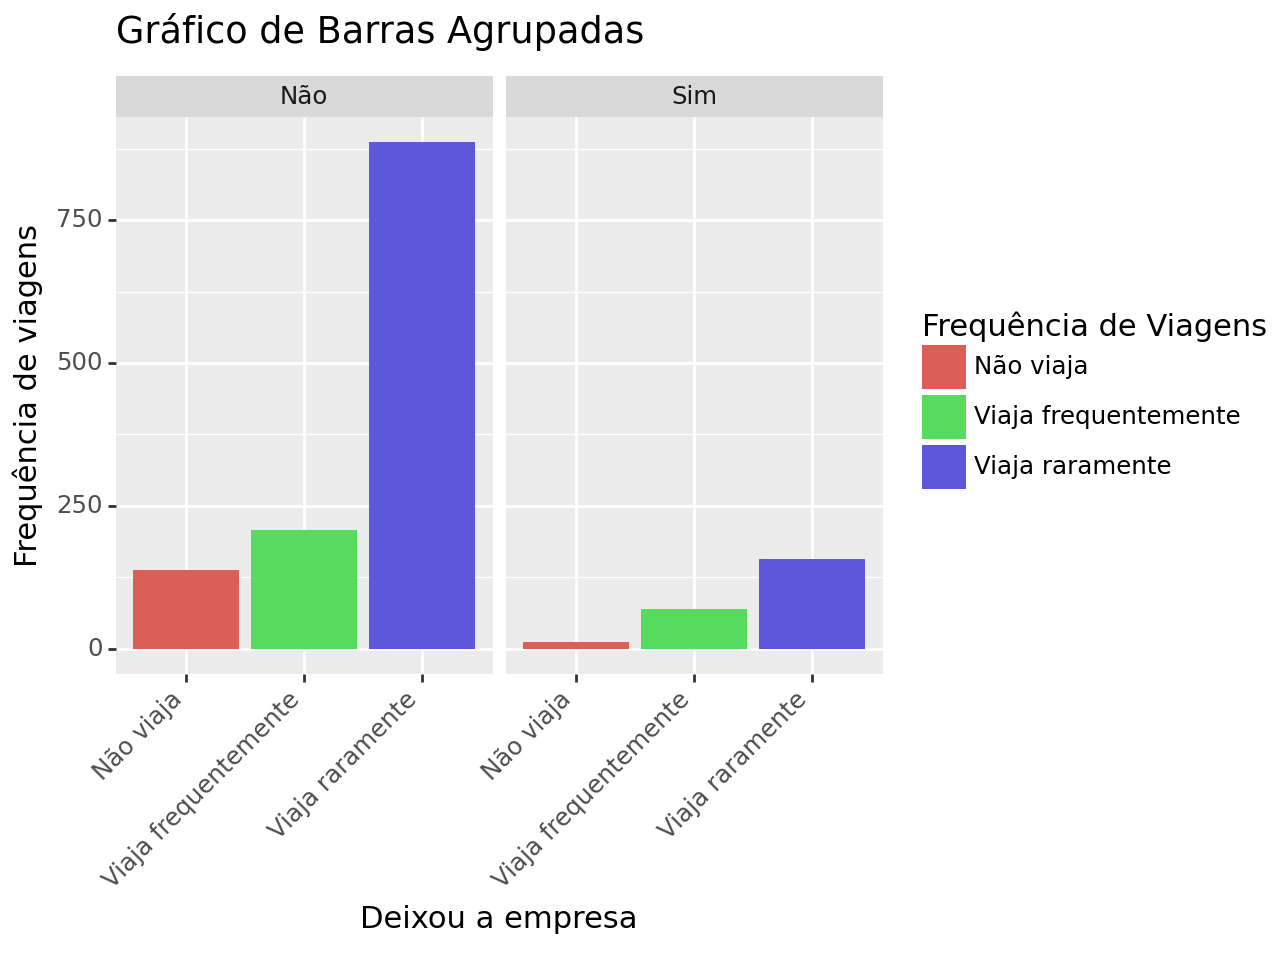

In [56]:
from plotnine import ggplot, aes, geom_bar, facet_wrap, scale_x_discrete, labs
from textwrap import wrap
from plotnine.themes import element_text

grafico = (
    ggplot(base, aes(x='Frequência de Viagens', fill='Frequência de Viagens')) + 
    geom_bar(position='dodge') + 
    labs(title='Gráfico de Barras Agrupadas', x='Deixou a empresa', y='Frequência de viagens') +
    facet_wrap('~Funcionário_deixou_a_empresa') +
    theme(axis_text_x=element_text(angle=45, hjust=1))
)
# Mostrando o gráfico
print(grafico)

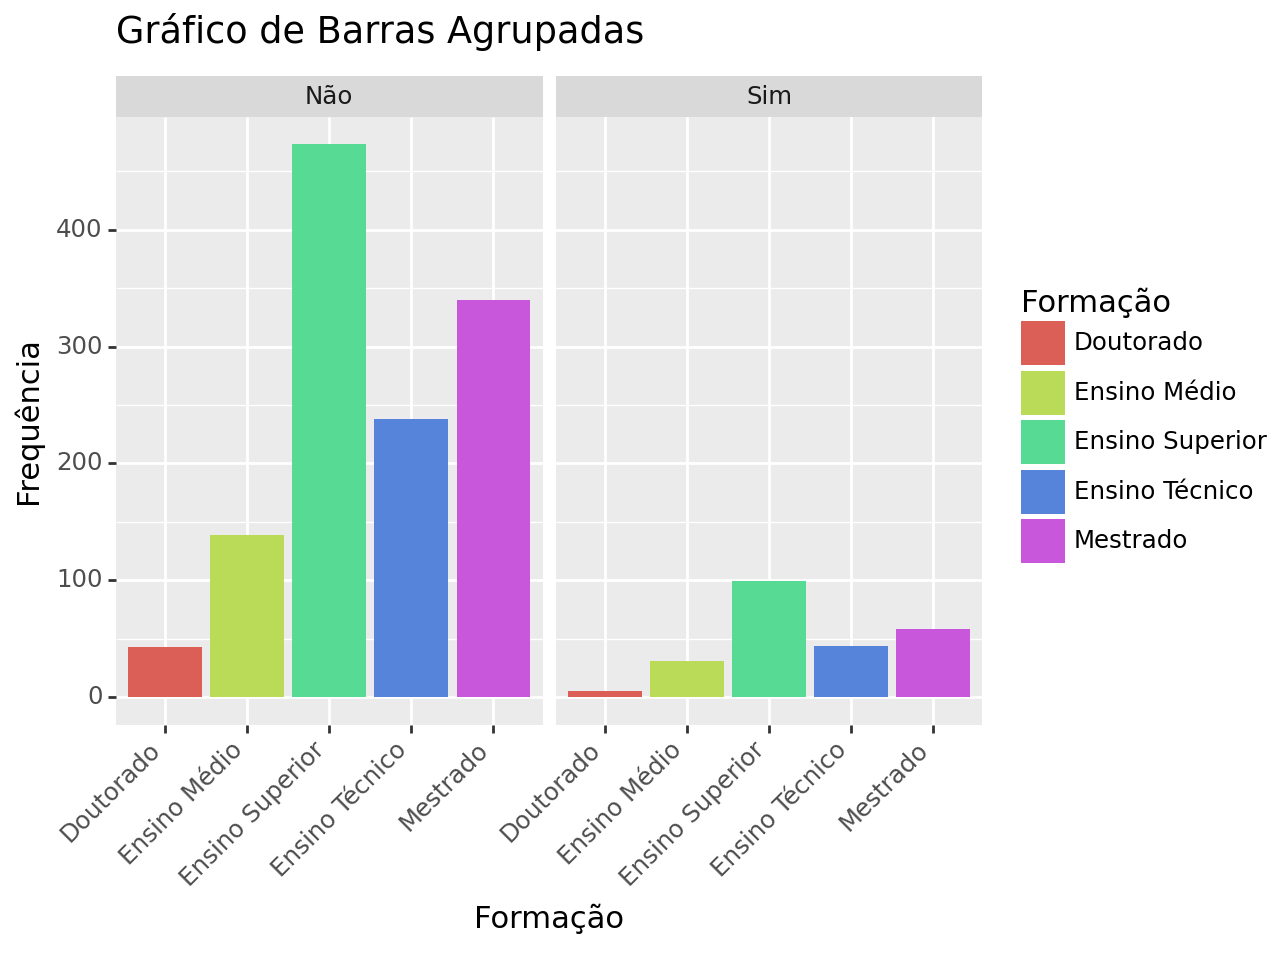

In [54]:
import matplotlib.pyplot as plt
from plotnine import ggplot, aes, geom_bar, facet_wrap, scale_x_discrete, labs
from textwrap import wrap
from plotnine.themes import element_text
grafico = (
    ggplot(base, aes(x='Formação', fill='Formação')) + 
    geom_bar(position='dodge') + 
    labs(title='Gráfico de Barras Agrupadas', x='Formação', y='Frequência') +
    facet_wrap('~Funcionário_deixou_a_empresa') +
    theme(axis_text_x=element_text(angle=45, hjust=1))  # Ajuste a largura do eixo x aqui
)

# Mostrando o gráfico
print(grafico)

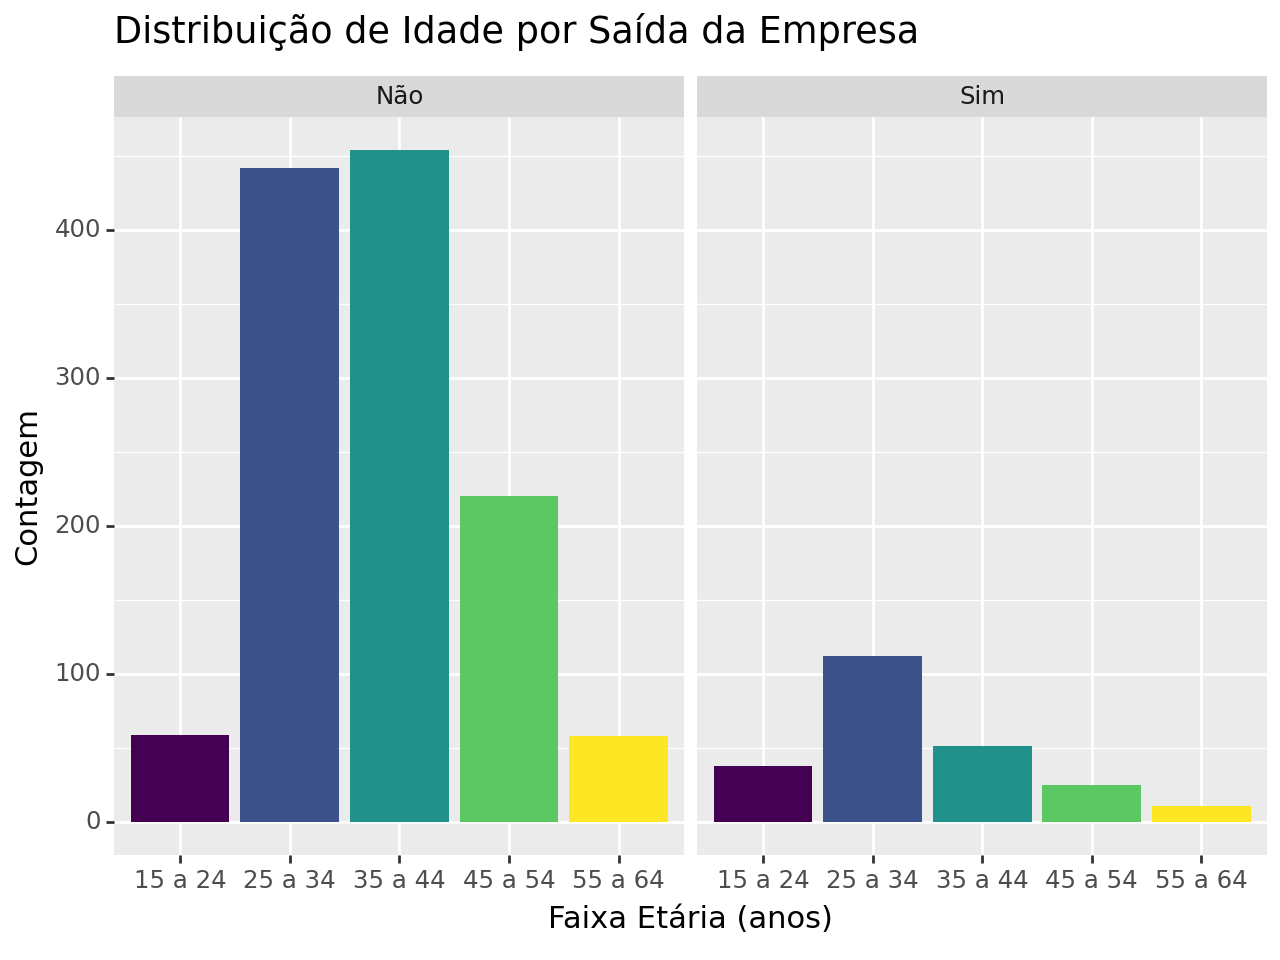

<Figure Size: (640 x 480)>

In [21]:


(ggplot(base, aes(x=pd.cut(base['Idade'], bins=range(15, 66, 10), right=False, labels=['15-24', '25-34', '35-44', '45-54', '55-64']), fill=pd.cut(base['Idade'], bins=range(15, 66, 10), right=False))) + 
 geom_bar(position='dodge', show_legend=False) + 
 facet_wrap('Funcionário_deixou_a_empresa') + 
 labs(title='Distribuição de Idade por Saída da Empresa', x='Faixa Etária (anos)', y='Contagem') + 
 scale_x_discrete(labels=lambda l: [label.replace('-', ' a ') for label in l]))

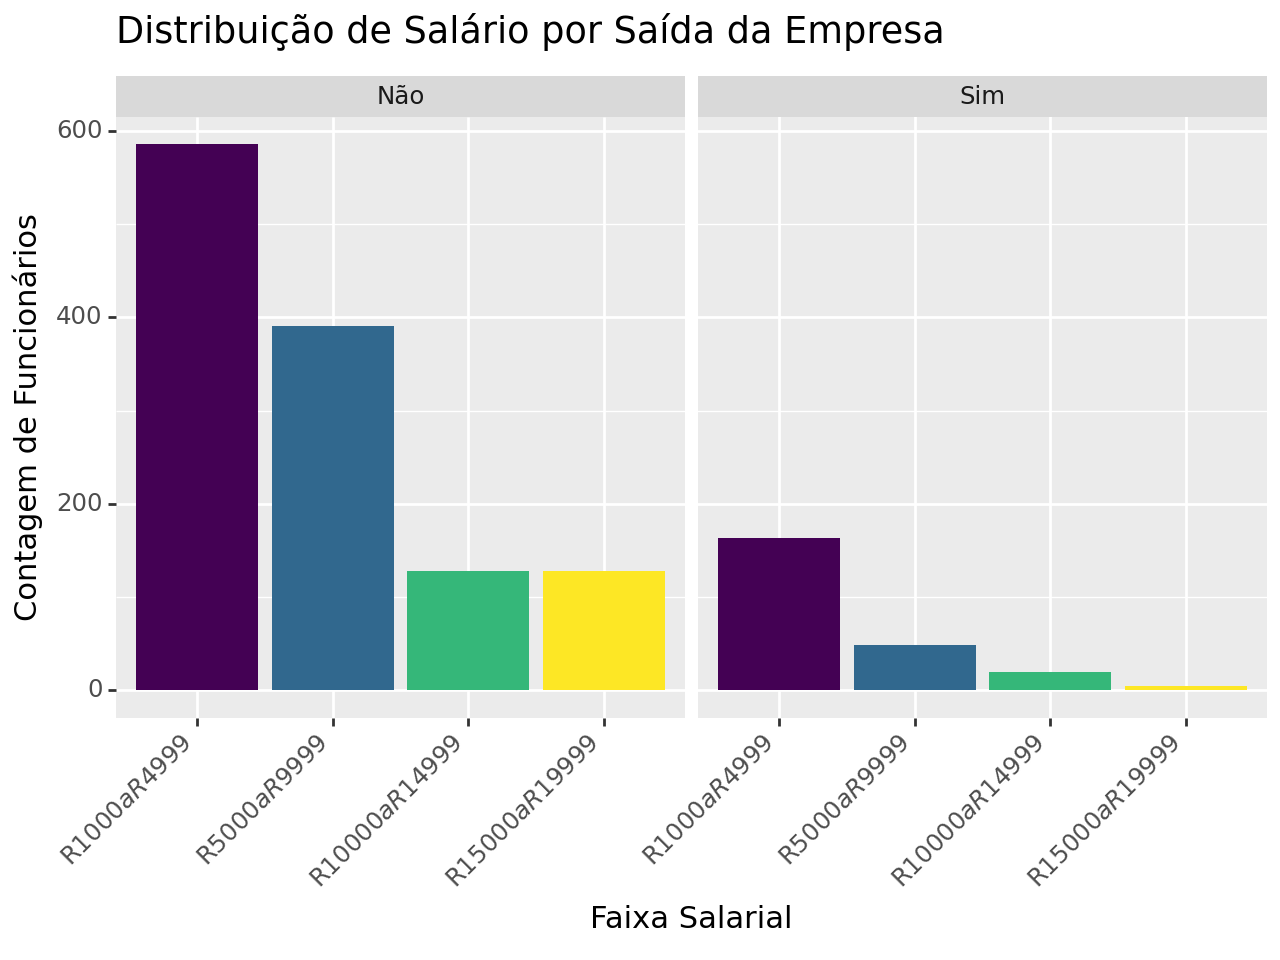

<Figure Size: (640 x 480)>

In [22]:
(ggplot(base, aes(x=pd.cut(base['Salário'], 
                  bins=[1000, 5000, 10000, 15000, 20000], 
                  right=False, 
                  labels=['1000-4999', '5000-9999', '10000-14999', '15000-19999']),
           fill=pd.cut(base['Salário'], 
                       bins=[1000, 5000, 10000, 15000, 20000], 
                       right=False))) + 
 geom_bar(position='dodge', show_legend=False) + 
 facet_wrap('Funcionário_deixou_a_empresa') + 
 labs(title='Distribuição de Salário por Saída da Empresa', 
      x='Faixa Salarial', 
      y='Contagem de Funcionários') + 
 scale_x_discrete(labels=lambda l: [f"R${label.replace('-', ' a R$')}" for label in l]) +
 theme(axis_text_x=element_text(angle=45, hjust=1)))

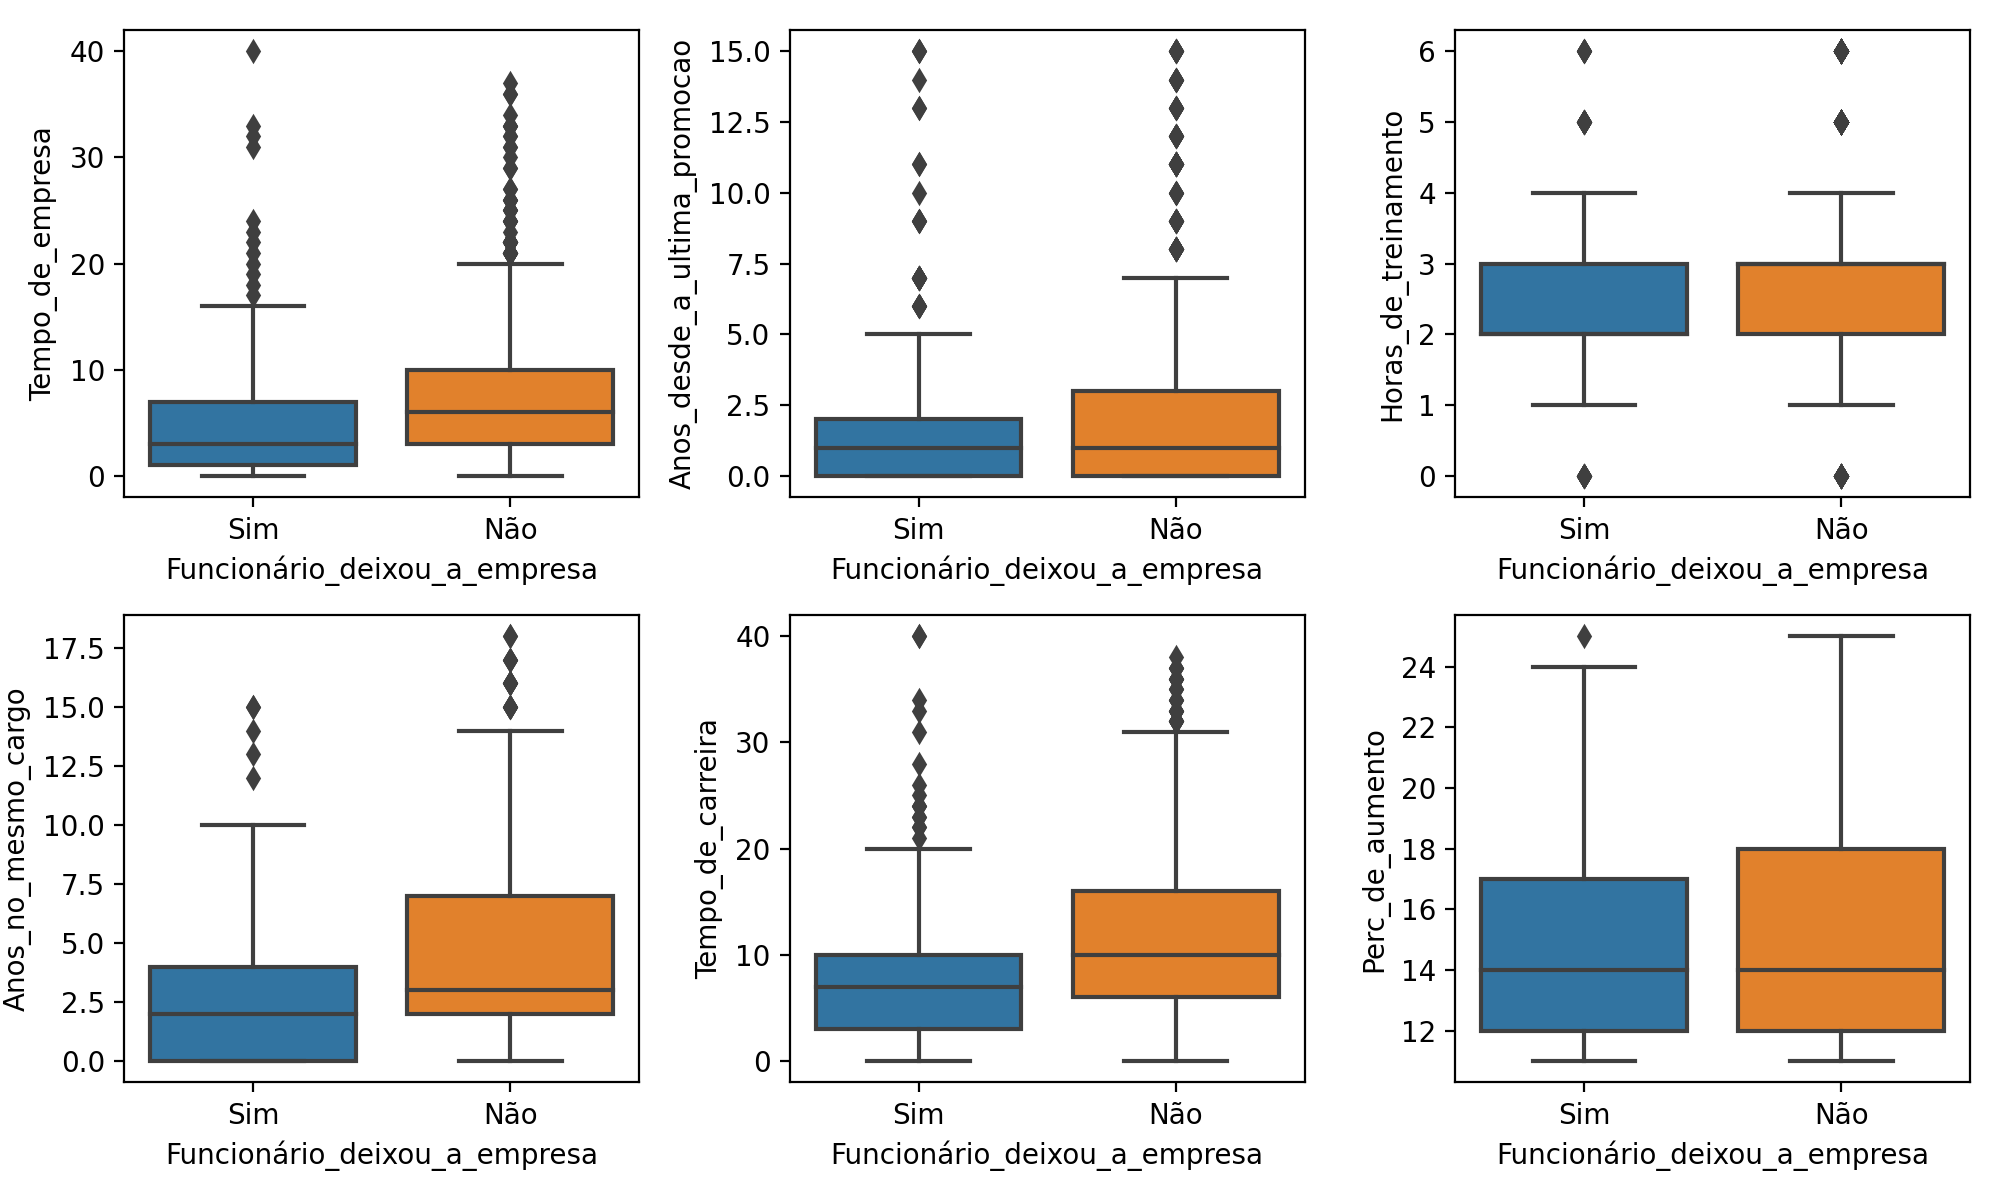

In [52]:

df = pd.DataFrame(base)

plt.figure(figsize=(10, 6)) 

plt.subplot(2, 3, 1)  # Cria o primeiro subplot para a variável 
sns.boxplot(x='Funcionário_deixou_a_empresa', y='Tempo_de_empresa', data=df)

plt.subplot(2, 3, 2)  # Cria o segundo subplot para a variável 
sns.boxplot(x='Funcionário_deixou_a_empresa', y='Anos_desde_a_ultima_promocao', data=df)

plt.subplot(2, 3, 3)  # Cria o segundo subplot para a variável 
sns.boxplot(x='Funcionário_deixou_a_empresa', y='Horas_de_treinamento', data=df)

plt.subplot(2, 3, 4)  # Cria o segundo subplot para a variável 
sns.boxplot(x='Funcionário_deixou_a_empresa', y='Anos_no_mesmo_cargo', data=df)

plt.subplot(2, 3, 5)  # Cria o segundo subplot para a variável 
sns.boxplot(x='Funcionário_deixou_a_empresa', y='Tempo_de_carreira', data=df)

plt.subplot(2, 3, 6)  # Cria o segundo subplot para a variável 
sns.boxplot(x='Funcionário_deixou_a_empresa', y='Perc_de_aumento', data=df)
plt.tight_layout()  # Ajusta o layout dos subplots
plt.show()

#### NOTA:
Faz sentido fazer boxplot? Pois o eixo x: 'sim' e 'não' são complementares. Não são comparáveis entre si. Eles fazem parte da mesma distribuição.? 

Os testes de diferença de mediana que deram dignificativos são os que possuem as medianas mais proximas (a partir da leitura dos box-plot) 

### Teste de Hipoteses

Para análise das variáveis quantitativas foram feitos os testes de hipótese não paramétrico de mann-whitnet. Verificamos nos testes que a variável horas de treinamento e anos desde a última promoção possuem medianas que diferem estatisticamente em relação a variável funcionário deixou a empresa 'sim' e 'não'. (obs: acho q não está errada, mas está confusa).

In [29]:
# Teste de Kruskal-Wallis para a variável "Idade"
grupo0 = df[df['Funcionário_deixou_a_empresa'] == "Sim"]['Tempo_de_empresa']
grupo1 = df[df['Funcionário_deixou_a_empresa'] == "Não"]['Tempo_de_empresa']
statistic, p_value = stats.mannwhitneyu(grupo0, grupo1)

print("Teste de Mann-Whitney U - Tempo de Empresa:")
print("Estatística do teste:", statistic)
print("Valor p:", p_value)

# Teste de Kruskal-Wallis para a variável "Idade"
grupo0 = df[df['Funcionário_deixou_a_empresa'] == "Sim"]['Anos_desde_a_ultima_promocao']
grupo1 = df[df['Funcionário_deixou_a_empresa'] == "Não"]['Anos_desde_a_ultima_promocao']
statistic, p_value = stats.mannwhitneyu(grupo0, grupo1)

print("Teste de Mann-Whitney U - Anos_desde_a_ultima_promocao:")
print("Estatística do teste:", statistic)
print("Valor p:", p_value)

# Teste de Kruskal-Wallis para a variável "Idade"
grupo0 = df[df['Funcionário_deixou_a_empresa'] == "Sim"]['Anos_com_o_mesmo_chefe']
grupo1 = df[df['Funcionário_deixou_a_empresa'] == "Não"]['Anos_com_o_mesmo_chefe']
statistic, p_value = stats.mannwhitneyu(grupo0, grupo1)

print("Teste de Mann-Whitney U - Anos_com_o_mesmo_chefe:")
print("Estatística do teste:", statistic)
print("Valor p:", p_value)

# Teste de Kruskal-Wallis para a variável "Idade"
grupo0 = df[df['Funcionário_deixou_a_empresa'] == "Sim"]['Anos_no_mesmo_cargo']
grupo1 = df[df['Funcionário_deixou_a_empresa'] == "Não"]['Anos_no_mesmo_cargo']
statistic, p_value = stats.mannwhitneyu(grupo0, grupo1)

print("Teste de Mann-Whitney U - Anos_no_mesmo_cargo:")
print("Estatística do teste:", statistic)
print("Valor p:", p_value)

# Teste de Kruskal-Wallis para a variável "Idade"
grupo0 = df[df['Funcionário_deixou_a_empresa'] == "Sim"]['Tempo_de_carreira']
grupo1 = df[df['Funcionário_deixou_a_empresa'] == "Não"]['Tempo_de_carreira']
statistic, p_value = stats.mannwhitneyu(grupo0, grupo1)

print("Teste de Mann-Whitney U - Tempo_de_carreira:")
print("Estatística do teste:", statistic)
print("Valor p:", p_value)

# Teste de Kruskal-Wallis para a variável "Idade"
grupo0 = df[df['Funcionário_deixou_a_empresa'] == "Sim"]['Perc_de_aumento']
grupo1 = df[df['Funcionário_deixou_a_empresa'] == "Não"]['Perc_de_aumento']
statistic, p_value = stats.mannwhitneyu(grupo0, grupo1)

print("Teste de Mann-Whitney U - Perc_de_aumento:")
print("Estatística do teste:", statistic)
print("Valor p:", p_value)

# Teste de Kruskal-Wallis para a variável "Idade"
grupo0 = df[df['Funcionário_deixou_a_empresa'] == "Sim"]['Horas_de_treinamento']
grupo1 = df[df['Funcionário_deixou_a_empresa'] == "Não"]['Horas_de_treinamento']
statistic, p_value = stats.mannwhitneyu(grupo0, grupo1)

print("Teste de Mann-Whitney U - Horas_de_treinamento:")
print("Estatística do teste:", statistic)
print("Valor p:", p_value)

# Teste de Kruskal-Wallis para a variável "Idade"
grupo0 = df[df['Funcionário_deixou_a_empresa'] == "Sim"]['Qte_ações_da_empresa']
grupo1 = df[df['Funcionário_deixou_a_empresa'] == "Não"]['Qte_ações_da_empresa']
statistic, p_value = stats.mannwhitneyu(grupo0, grupo1)

print("Teste de Mann-Whitney U - Qte_ações_da_empresa:")
print("Estatística do teste:", statistic)
print("Valor p:", p_value)

# Teste de Kruskal-Wallis para a variável "Idade"
grupo0 = df[df['Funcionário_deixou_a_empresa'] == "Sim"]['Salário']
grupo1 = df[df['Funcionário_deixou_a_empresa'] == "Não"]['Salário']
statistic, p_value = stats.mannwhitneyu(grupo0, grupo1)

print("Teste de Mann-Whitney U - Salário:")
print("Estatística do teste:", statistic)
print("Valor p:", p_value)

# Teste de Kruskal-Wallis para a variável "Idade"
grupo0 = df[df['Funcionário_deixou_a_empresa'] == "Sim"]['Qte_Empresas_Trabalhadas']
grupo1 = df[df['Funcionário_deixou_a_empresa'] == "Não"]['Qte_Empresas_Trabalhadas']
statistic, p_value = stats.mannwhitneyu(grupo0, grupo1)

print("Teste de Mann-Whitney U - Qte_Empresas_Trabalhadas:")
print("Estatística do teste:", statistic)
print("Valor p:", p_value)

Teste de Mann-Whitney U - Tempo de Empresa:
Estatística do teste: 102582.0
Valor p: 2.916191369956416e-13
Teste de Mann-Whitney U - Anos_desde_a_ultima_promocao:
Estatística do teste: 134374.0
Valor p: 0.0411791057847264
Teste de Mann-Whitney U - Anos_com_o_mesmo_chefe:
Estatística do teste: 106361.5
Valor p: 1.8067542583144407e-11
Teste de Mann-Whitney U - Anos_no_mesmo_cargo:
Estatística do teste: 105214.0
Valor p: 4.429559530312778e-12
Teste de Mann-Whitney U - Tempo_de_carreira:
Estatística do teste: 100567.0
Valor p: 2.399569364798952e-14
Teste de Mann-Whitney U - Perc_de_aumento:
Estatística do teste: 140726.5
Valor p: 0.36551461755468617
Teste de Mann-Whitney U - Horas_de_treinamento:
Estatística do teste: 134785.5
Valor p: 0.04729570730410349
Teste de Mann-Whitney U - Qte_ações_da_empresa:
Estatística do teste: 109611.0
Valor p: 4.0133750819833e-11
Teste de Mann-Whitney U - Salário:
Estatística do teste: 100620.5
Valor p: 2.950830917288873e-14
Teste de Mann-Whitney U - Qte_Empr

In [ ]:
target_col = [col for col in base.columns if 'deixou' in col.lower()][0]
print(f"Usando coluna alvo: {target_col}")

In [34]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

# ----------------------------------------------------------
# 1. PRÉ-PROCESSAMENTO
# ----------------------------------------------------------

# Criar cópia e renomear coluna alvo (removendo acento)
df = base.rename(columns={'Funcionário_deixou_a_empresa': 'Funcionario_deixou_a_empresa'})

# Verificar colunas numéricas e categóricas
print("Variáveis numéricas:\n", df.select_dtypes(include=['int64', 'float64']).columns.tolist())
print("\nVariáveis categóricas:\n", df.select_dtypes(include=['object']).columns.tolist())

# Codificar variável alvo (Sim/Não -> 1/0)
df['Funcionario_deixou_a_empresa'] = LabelEncoder().fit_transform(df['Funcionario_deixou_a_empresa'])

# One-Hot Encoding para categóricas (exceto ID)
categorical_cols = df.select_dtypes(include=['object']).columns.drop('Funcionario_deixou_a_empresa', errors='ignore')
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Remover ID (não é preditor)
df = df.drop('ID', axis=1, errors='ignore')

# ----------------------------------------------------------
# 2. SELEÇÃO STEPWISE AUTOMATIZADA
# ----------------------------------------------------------

def stepwise_selection(X, y, initial_list=[], threshold_in=0.05, threshold_out=0.1, verbose=True):
    included = list(initial_list)
    while True:
        changed = False
        
        # Forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.Logit(y, sm.add_constant(pd.DataFrame(X[included + [new_column]]))).fit(disp=0)
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            if verbose: print(f'Adicionada: {best_feature} (p-value: {best_pval:.4f})')
            changed = True
            
        # Backward step
        model = sm.Logit(y, sm.add_constant(pd.DataFrame(X[included]))).fit(disp=0)
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max()
        if worst_pval > threshold_out:
            changed = True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose: print(f'Removida: {worst_feature} (p-value: {worst_pval:.4f})')
                
        if not changed: break
            
    return included

# Executar seleção
X = df.drop('Funcionario_deixou_a_empresa', axis=1)
y = df['Funcionario_deixou_a_empresa']
selected_vars = stepwise_selection(X, y)

print("\nVariáveis selecionadas:", selected_vars)

# ----------------------------------------------------------
# 3. MODELO FINAL E INTERPRETAÇÃO
# ----------------------------------------------------------

# Modelo com variáveis selecionadas
X_final = sm.add_constant(X[selected_vars])
model = sm.Logit(y, X_final).fit()
print(model.summary())

# Odds Ratios e importância
odds_ratios = pd.DataFrame({
    'Variavel': selected_vars,
    'OR': np.exp(model.params[1:]),  # Excluir intercepto
    'p-value': model.pvalues[1:]
}).sort_values('OR', ascending=False)

print("\nOdds Ratios das variáveis selecionadas:")
print(odds_ratios)

# ----------------------------------------------------------
# 4. AVALIAÇÃO DO MODELO (OPCIONAL)
# ----------------------------------------------------------
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_final) > 0.5
print("\nRelatório de Classificação:")
print(classification_report(y, y_pred))
print(f"AUC-ROC: {roc_auc_score(y, model.predict(X_final)):.3f}")

Variáveis numéricas:
 ['ID', 'Idade', 'Distância_do_trabalho', 'Salário', 'Qte_Empresas_Trabalhadas', 'Perc_de_aumento', 'Qte_ações_da_empresa', 'Tempo_de_carreira', 'Horas_de_treinamento', 'Tempo_de_empresa', 'Anos_no_mesmo_cargo', 'Anos_desde_a_ultima_promocao', 'Anos_com_o_mesmo_chefe']

Variáveis categóricas:
 ['Funcionario_deixou_a_empresa', 'Frequência de Viagens', 'Formação', 'E-Sat', 'Gênero', 'Estado_Civil', 'Faz_hora_extras?', 'Equilibrio_de_Vida']
Adicionada: Faz_hora_extras?_Sim (p-value: 0.0000)


C:\Users\tania\AppData\Local\Temp\ipykernel_10280\3574233329.py:38: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
C:\Users\tania\AppData\Local\Temp\ipykernel_10280\3574233329.py:38: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.


Adicionada: Estado_Civil_Solteiro (p-value: 0.0000)


C:\Users\tania\AppData\Local\Temp\ipykernel_10280\3574233329.py:38: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.


Adicionada: Tempo_de_carreira (p-value: 0.0000)
Adicionada: E-Sat_Baixo (p-value: 0.0000)


...

Adicionada: Anos_no_mesmo_cargo (p-value: 0.0364)
Removida: Tempo_de_carreira (p-value: 0.1238)


C:\Users\tania\AppData\Local\Temp\ipykernel_10280\3574233329.py:38: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.


Adicionada: Horas_de_treinamento (p-value: 0.0400)

Variáveis selecionadas: ['Faz_hora_extras?_Sim', 'Estado_Civil_Solteiro', 'E-Sat_Baixo', 'Qte_Empresas_Trabalhadas', 'Frequência de Viagens_Viaja frequentemente', 'Distância_do_trabalho', 'Equilibrio_de_Vida_Ruim', 'Anos_desde_a_ultima_promocao', 'Anos_com_o_mesmo_chefe', 'Idade', 'Frequência de Viagens_Viaja raramente', 'Salário', 'Anos_no_mesmo_cargo', 'Horas_de_treinamento']


C:\Users\tania\AppData\Local\Temp\ipykernel_10280\3574233329.py:38: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.


Optimization terminated successfully.
         Current function value: 0.334448
         Iterations 7
                                Logit Regression Results                                
Dep. Variable:     Funcionario_deixou_a_empresa   No. Observations:                 1470
Model:                                    Logit   Df Residuals:                     1455
Method:                                     MLE   Df Model:                           14
Date:                          Wed, 30 Apr 2025   Pseudo R-squ.:                  0.2428
Time:                                  14:14:46   Log-Likelihood:                -491.64
converged:                                 True   LL-Null:                       -649.29
Covariance Type:                      nonrobust   LLR p-value:                 7.552e-59
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

### CONCLUSÃO

Dado que as variaveis significativas para a analise IV (faz horas extra? e estado civil solteiro) e as variaveis continuas que 
o teste de hipotese diferiram (anos desde a última promoção e horas de treinamento) indica-se ao RH:

Uma conversa com os colaboradores que reponderam 'sim' para 'faz horas extras?' para melhror entender o porque fazem horas extras. Se estao buscando uma promoção/ aumento. ou se as horas de treinamento estão sendo muito puxadas. Além disso, priorizar a contratação de pessoas que estejam em uma relação estavel.
